PROJECT 2:
Pakistani Politician Image Classification using CNN and ResNet50

Dataset:
• 16 Classes (Politicians)
• Train / Validation / Test Split

Team Members:

• Mashal → Dataset Collection + ResNet50 (Transfer Learning)+ Evaluation

• Ayesha → CNN Model + Preprocessing + Base Training

• Shiza → Data Augmentation + Graphs + Results Visualization

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 🔹 Importing Required Libraries
We import TensorFlow, NumPy, Matplotlib, Seaborn, and Scikit-learn tools for building and evaluating CNN and ResNet50 models.

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, classification_report

## 🔹 Dataset Paths Setup
We define the directory paths for training, validation, and testing datasets stored in Google Drive.

In [22]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

base_dir = "/content/drive/MyDrive/Dataset/split_dataset"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/val"
test_dir  = f"{base_dir}/test"

print("Train Path:", train_dir)
print("Validation Path:", val_dir)
print("Test Path:", test_dir)

Train Path: /content/drive/MyDrive/Dataset/split_dataset/train
Validation Path: /content/drive/MyDrive/Dataset/split_dataset/val
Test Path: /content/drive/MyDrive/Dataset/split_dataset/test


## 🔹 Data Augmentation
To improve model generalization, we apply image augmentation such as rotation, zoom, brightness variation, and flipping.

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [24]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 712 images belonging to 16 classes.
Found 138 images belonging to 16 classes.
Found 106 images belonging to 16 classes.


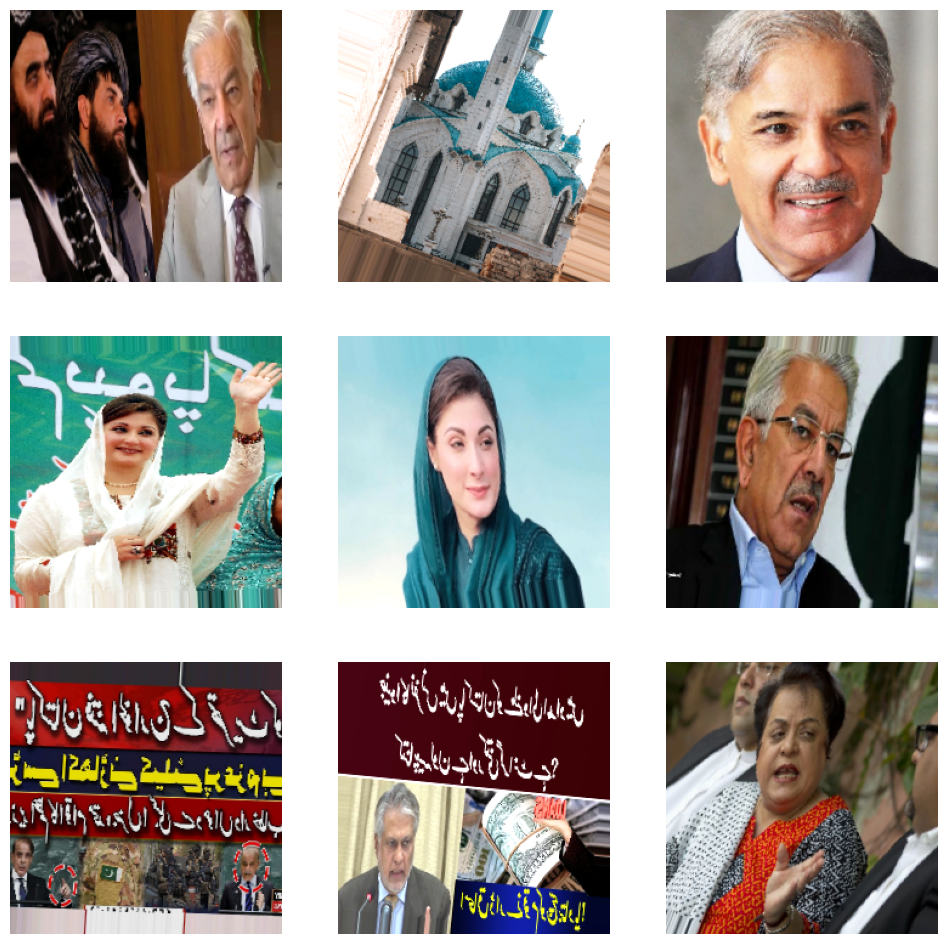

In [25]:
images, labels = next(train_data)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = '/content/drive/MyDrive/Dataset/split_dataset'

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    f'{base_dir}/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    f'{base_dir}/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    f'{base_dir}/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 712 images belonging to 16 classes.
Found 138 images belonging to 16 classes.
Found 106 images belonging to 16 classes.


## 🔹 Dataset Visualization
We display sample images from the training set to understand dataset structure.

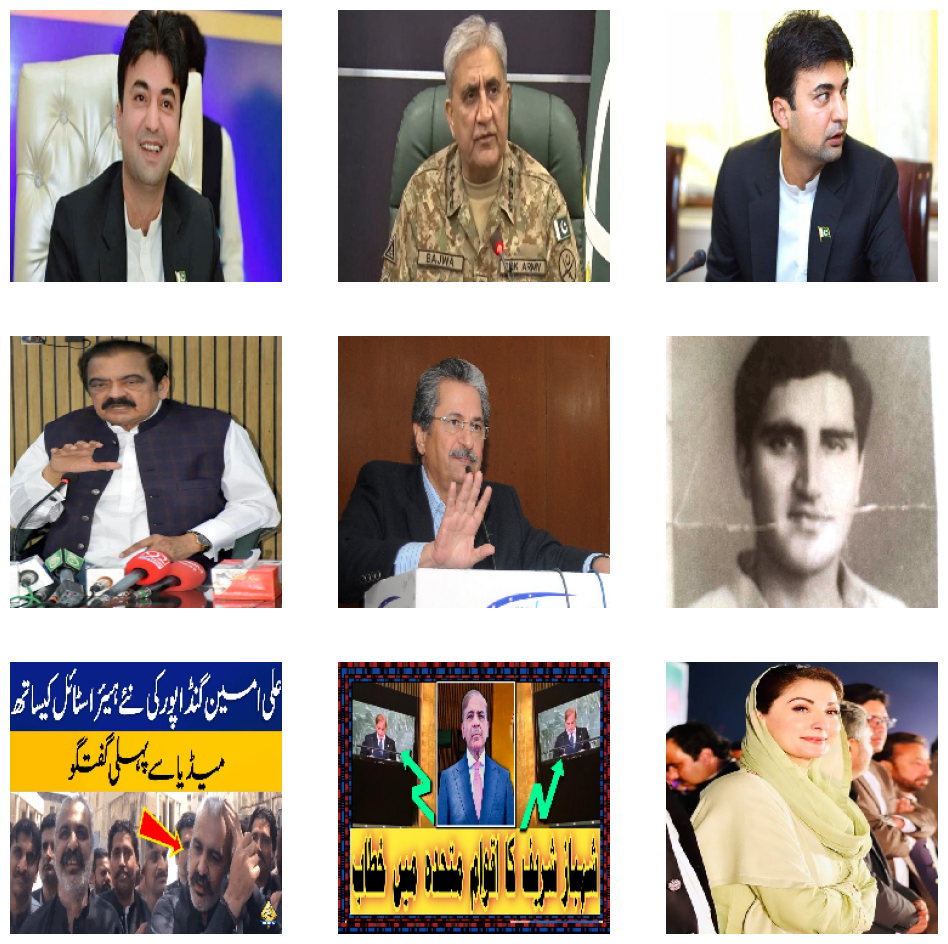

In [28]:
images, labels = next(train_data)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

## 🔹 CNN Model Architecture
A basic Convolutional Neural Network is built using Conv2D, MaxPooling, and Dense layers for classification.

In [31]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 🔹 CNN Model Training
The CNN model is trained using training data and validated using validation set

In [32]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 327s 14s/step - accuracy: 0.0787 - loss: 3.0840 - val_accuracy: 0.1014 - val_loss: 2.7647
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 569ms/step - accuracy: 0.0927 - loss: 2.7420 - val_accuracy: 0.1087 - val_loss: 2.7288
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 570ms/step - accuracy: 0.1138 - loss: 2.6864 - val_accuracy: 0.1449 - val_loss: 2.6958
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 587ms/step - accuracy: 0.1840 - loss: 2.5496 - val_accuracy: 0.1812 - val_loss: 2.6813
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 563ms/step - accuracy: 0.3188 - loss: 2.2326 - val_accuracy: 0.2609 - val_loss: 2.4958
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 545ms/step - accuracy: 0.4958 - loss: 1.6708 - val_accuracy: 0.2971 - val_loss: 2.6027
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 566ms/step - accuracy: 0.6671 - loss: 1.1652 - val_accuracy: 0.3261 - val_loss: 2.6054
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 559ms/step - accuracy: 0.7823 - loss: 0.7290 - val_accur